## Lab 1 Introduction to Python

In ELEC3705 lab, we will mainly focus on linear-algebra-based computation. To do so, we need to import the NumPy library, which allows you to define data types as multi-dimensional arrays and matrices. NumPy also provides a large collection of mathematical functions to operate on these objects. If you have never used python before, don't be intimidated, we will go through all the basics!
<br><br>

We will be using Jupyter notebooks throughout this course, where you can make markdowns, comment in scientific notation, and run the program cell by cell. Below is a basic introduction to Python basics that we will run through during the first lab.

### 1. Import libraries for fast vector-based compuatation
NumPy and SciPy packages should be already installed when you install Anaconda. There is no need to download them again
<br>
Any other packages you want to import can also be included here at the beginning of the document or you can import them as and when you need them.

In [1]:
import numpy as np # imports all functions and classes from the numpy library, we'll use the prefix np to access them
import scipy as sp
from numpy import linalg as LA # linalg is a subpackage of numpy
from scipy.linalg import logm, expm # linalg is a subpcackage of scipy, if we import the functions we don't neet to call them with the prefix sp.linalg

### 2. List, Vectors and Matrixes 

The python default method of storing an array of numbers is the list []. The advantage of a list is that you can add anything to a list. You could add a dictionary ({'a': 1}), floating point (1.1), integer 1 and even more lists ([]) in the same list.

In [2]:
list1 = [1, 2, 3]
list1

[1, 2, 3]

In [4]:
len(list1)

3

In [5]:
list2 = [{'a': 1}, 1.1,  1, [1, 2]]
list2

[{'a': 1}, 1.1, 1, [1, 2]]

However lists don't beheave like vectors. This makes them not the ideal object to do linear algebra and thus quantum physics with.

See for instance what happens if we multiply a list with a number:

In [6]:
v_list = [1,2]
v_list*2

[1, 2, 1, 2]

Instead we will use the 'array' object from the numpy (imported as np) module. The function np.array() takes a list as input and turns it into a numpy array. The numpy array is much more suited to use for numerics.

In [7]:
v_array = np.array([1,2])
v_array*2

array([2, 4])

Unlike lists, the elements of a numpy array should all be of the same data type. When making a numpy array the data type is set based on your initial inputs. Often times you will start of with integers only. Numpy arrays are pretty smart and will switch data type if necessary, but you need to watch out with complex numbers! 

In [8]:
np.array([1, 0]).dtype

dtype('int64')

In [9]:
np.array([1.1, 0]).dtype

dtype('float64')

In [10]:
np.array([1j, 0]).dtype

dtype('complex128')

### 2.2 Vectors and shape

The arrays we have seen so far don't have a vector like 'shape' yet. There is no difference between a row or column vector and thus also not between a 'bra' and 'ket'. We can add dimensions to a np.array by putting lists inside of lists.

In [3]:
x0 = np.array([1, 0])
x0.shape # only a single dimension is defined

(2,)

In [4]:
x1 = np.array([[1, 0]])
print('shape of x1:', x1.shape) # now it has two dimensions, but the second dimension has size 1
x1

shape of x1: (1, 2)


array([[1, 0]])

In [5]:
x2 = np.array([[1], [0]])
print('shape of x2:', x2.shape) # the dimensions are swapped compared to x1
x2

shape of x2: (2, 1)


array([[1],
       [0]])

And now we also know how to make a matrix

In [6]:
m1 = np.array([[1, 0], [0, 1]])
print('shape of m1:', m1.shape)
m1

shape of m1: (2, 2)


array([[1, 0],
       [0, 1]])

#### <font color='green'>Task</font> : Intialise $| \downarrow \rangle $ and $| \uparrow \rangle $ and using np.array. Calculate the corresponding bras $\langle \downarrow |$ and $\langle \uparrow |$ 

(check the lecture slides if you don't know what vectors you need)

In [8]:
# initializing the ket vectors
ket_up = np.array([[1], [0]])  # column vector
ket_down = np.array([[0], [1]])  # column vector

# initializing the bra vectors
bra_up = np.array([[1, 0]])  # row vector
bra_down = np.array([[0, 1]])  # row vector

# calculating the bra vectors from the ket vectors
bra_up = np.conj(ket_up.T)  # conjugate transpose of ket_up
bra_down = np.conj(ket_down.T)  # conjugate transpose of ket_down


####  <font color='green'>Task</font>: Intialise the +x (+) state using np.array

$|+\rangle = (| \uparrow \rangle + | \downarrow \rangle)/\sqrt(2)$  

In [9]:
# Answer

plus = (ket_up + ket_down) / np.sqrt(2)
plus



array([[0.70710678],
       [0.70710678]])

Two usefull built in functions for regulating the shape of an array are np.transpose (.T) and np.reshape (.reshape()) 

In [52]:
bra = np.array([[1, 0]]) # row vector
ket = np.transpose(bra) # column vector
ket

array([[1],
       [0]])

In [53]:
bra.T

array([[1],
       [0]])

In [57]:
array = np.array([0, 1, 2, 3, 4, 5])
matrix = array.reshape((2, 3)) # reshape to a 2x3 matrix
matrix

array([[0, 1, 2],
       [3, 4, 5]])

####  <font color='green'>Task</font>: Turn the 'shapeless' array test_array into a column vector (with shape (2, 1)).

In [13]:
test_array = np.array([1, 1])
print(test_array.shape)

# answer 
test_array = test_array.reshape((2, 1))
print(test_array.shape)
test_array

(2,)
(2, 1)


array([[1],
       [1]])

### 2.3 storing vectors and indexing arrays

In [41]:
memory = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
memory[0]

np.int64(0)

In [42]:
memory[3]

np.int64(3)

In [43]:
memory[0:4] # slicing, note that the last index is not included

array([0, 1, 2, 3])

In [44]:
memory[-1]

np.int64(9)

In [50]:
memory_2d = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]])
print(memory_2d.shape)
memory_2d[0, 0] # first row, first column

(4, 3)


np.int64(0)

In [48]:
memory_2d[0, :] 

array([0, 1, 2])

In [49]:
memory_2d[:, 0] 

array([0, 3, 6, 9])

We can store values in an existing array by overwriting them

In [62]:
memory[3] = 10
memory

array([ 0,  1,  2, 10,  4,  5,  6,  7,  8,  9])

In [67]:
memory_2d[:, 0] = np.array([-1, -2, -3, -4])
memory_2d

array([[-1,  1,  2],
       [-2,  4,  5],
       [-3,  7,  8],
       [-4, 10, 11]])

We can store vectors (for instance quantum states) as a bunch of individual arrays in a list

In [78]:
up = np.array([[1], [0]])
down = np.array([[0], [1]])
state_list = [up, down, up, down]

In [79]:
state_list[3]

array([[0],
       [1]])

In [81]:
state_list.append(np.array([[1], [1]])) # a usefull function for adding things to a list
state_list

[array([[1],
        [0]]),
 array([[0],
        [1]]),
 array([[1],
        [0]]),
 array([[0],
        [1]]),
 array([[1],
        [1]]),
 array([[1],
        [1]])]

You might want to store the states more ellegantly using a single numpy array

In [82]:
np.array([[1, 0, 1, 0, 1], [0, 1, 0, 1, 0]])

array([[1, 0, 1, 0, 1],
       [0, 1, 0, 1, 0]])

### There is a common problem with assigning kets to a numpy array! When you ask for a column of a numpy array it will 'loose its shape'. If you then want to overwrite this column with a ket (a column vector) it will complain about the shapes not matching!

In [17]:
memory2 = np.array([[0, 0, 0, 0], [0, 0, 0, 0]])
memory2

array([[0, 0, 0, 0],
       [0, 0, 0, 0]])

In [87]:
memory2[:, 3] # length 2 so it is clearly a column of the previous array

array([0, 0])

In [88]:
memory2[:, 3].shape # shape is (2,) so it has lost its second dimension

(2,)

In [89]:
memory2[:, 3] = up # pultting a ket in the array will now not fit

ValueError: could not broadcast input array from shape (2,1) into shape (2,)

In [91]:
memory2[:, 3] = up.T # putting a bra instead would work

In [93]:
memory2[:, 3] = up.reshape(2) # or reshaping

####  <font color='green'>Task</font>: Fill up the ket_memory array with all $|\uparrow \rangle$ kets and bra_memory with all $\langle \uparrow |$ bras

In [23]:
ket_memory = np.array([[0, 0, 0, 0], [0, 0, 0, 0]])
bra_memory = np.array([[0, 0], [0, 0], [0, 0], [0, 0]])

# answer
up_ket = np.array([[1], [0]])
up_bra = up_ket.T


ket_memory[:, 0] = up_ket.T
ket_memory[:, 1] = up_ket.T
ket_memory[:, 2] = up_ket.T
ket_memory[:, 3] = up_ket.T

for i in range(4):
    bra_memory[i, :] = up_bra
bra_memory

array([[1, 0],
       [1, 0],
       [1, 0],
       [1, 0]])

In [21]:
ket_memory

array([[1, 1, 1, 1],
       [0, 0, 0, 0]])

### 2.4. Matrix and the matrix product

####  <font color='green'>Task</font>: Initialize Pauli matrices $\sigma_x$, $\sigma_y$ and $\sigma_z$

(See slides if necessary)

In [24]:
# Answer

sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
sigma_x, sigma_y, sigma_z


(array([[0, 1],
        [1, 0]]),
 array([[ 0.+0.j, -0.-1.j],
        [ 0.+1.j,  0.+0.j]]),
 array([[ 1,  0],
        [ 0, -1]]))

The normal product * between np.arrays is ment for so called vectorisation of a calculation that would otherwise require some kind of loop.
This can be usefull in other cases but it is not what we need for our linear algebra.

In [ ]:
# It's not Matrix vector multiplication!
m = np.array([[2,0],[0,2]])
v = np.array([[1],[0]])

m*v

array([[2, 0],
       [0, 0]])

In stead to do a proper matrix product (or matrix vector product) we use the @

In [ ]:
m@v

array([[1],
       [3]])

####  <font color='green'>Task</font>: Create the matrix $U = \begin{pmatrix} \epsilon & \Delta \\ \Delta & -\epsilon \end{pmatrix}$, where $\epsilon = 1$, and $\Delta = 0.1$. Apply the matrix to the $|\uparrow \rangle$ state.  

In [27]:
# answer 
epsilon = 1
delta = 0.1

U = epsilon * sigma_z + delta * sigma_x
print(U)

U @ up_ket

[[ 1.   0.1]
 [ 0.1 -1. ]]


array([[1. ],
       [0.1]])

####  <font color='green'>Task</font>: Calculate the overlap of the down state and the up state, which is given by the following product: $\langle \downarrow | \uparrow \rangle $

In [29]:
# answer 
down_bra = np.array([[0, 1]])
up_ket = np.array([[1], [0]])

down_bra @ up_ket



array([[0]])

### 2.5. Some built-in functions to intialise vectors and matrices

In [14]:
# Identity Matrix
identity_matrix = np.identity(2)
identity_matrix

array([[1., 0.],
       [0., 1.]])

In [15]:
# Value starts from 0 in python
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [16]:
np.arange(2,10,2)

array([2, 4, 6, 8])

In [17]:
v1 = np.arange(10,1,-1) # left included, right exculded
v1

array([10,  9,  8,  7,  6,  5,  4,  3,  2])

In [18]:
v2 = np.linspace(1,10,20) # left included, right exculded
print('len(v2):', len(v2))
v2


len(v2): 20


array([ 1.        ,  1.47368421,  1.94736842,  2.42105263,  2.89473684,
        3.36842105,  3.84210526,  4.31578947,  4.78947368,  5.26315789,
        5.73684211,  6.21052632,  6.68421053,  7.15789474,  7.63157895,
        8.10526316,  8.57894737,  9.05263158,  9.52631579, 10.        ])

In [19]:
np.zeros((2,3))

array([[0., 0., 0.],
       [0., 0., 0.]])

In [20]:
np.ones((2,3)) #2*3 2-d array(matrix)


array([[1., 1., 1.],
       [1., 1., 1.]])

Another build in function we will be using a lot is the matrix exponential which comes from scipy. It should already be imported so you can just call it.

In [37]:
mat = np.array([[0, 1], 
                [2, 0]])

In [ ]:
expm(mat) # since we imported the function explicityly we don't need to do scipy.linalg.expm

array([[2.17818356, 1.36829887],
       [2.73659774, 2.17818356]])

In [39]:
np.exp(mat)

array([[1.        , 2.71828183],
       [7.3890561 , 1.        ]])

####  <font color='green'>Task</font>: What is the difference between scipy's 'expm' function and np.exp?

ANSWER: np.exp() takes the exponent of every element of the matrix ( $ \begin{pmatrix} e^0 & e^1 \\ e^2 & e^0 \end{pmatrix} $), where expm (from scipy) takes a proper matrix exponential ($e^{\begin{pmatrix} 0 & 1 \\ 2 & 0 \end{pmatrix}}$). Computing a matrix exponent generally requires either a taylor expension or for you to first diagonalize the matrix. The latter works because for a diagonal matrix we can simply take the exponents of all the diagonals ( $ e^{\begin{pmatrix} a & 0 \\ 0 & b \end{pmatrix}} = \begin{pmatrix} e^a & 0 \\ 0 & e^b \end{pmatrix} $)

Both can be tedious to do by hand so luckily we can use expm()!

## 3. Eigenvectors and Eigenvalues

Eigenvalues and eigen vectors will be important later on. It is good to know how to calculate them by hand but luckily we can also ask numpy to give them for us.

In [33]:
sigma_z = np.array([[1,0],[0,-1]]) 
sigma_x = np.array([[0,1],[1,0]]) 
sigma_y = np.array([[0,-1j], [1j, 0]]) 

vals, vecs = LA.eig(sigma_x) #remember LA is how we called the submodule np.linalg

print("Eigenvalues are: \n", vals)
print("Eigenvectors are: \n", vecs)
print(vecs[:,1]) # Note eigenvectors are in column vector

Eigenvalues are: 
 [ 1. -1.]
Eigenvectors are: 
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
[-0.70710678  0.70710678]


####  <font color='green'>Task</font>: Compare the eigenvalues of the three pauli matrices (sigma_x, sigma_y and sigma_z)

In [36]:
# all pauli matrices have the same eigenvalues (+1, -1). 
xvals, vecs = LA.eig(sigma_x) 
yvals, yvecs = LA.eig(sigma_y)
zvals, zvecs = LA.eig(sigma_z)
xvals, yvals, zvals

(array([ 1., -1.]), array([ 1.+0.j, -1.+0.j]), array([ 1., -1.]))

## 4. For loop

Loops automate repetitive code. In this course we will only need the 'for' loop which is demonstrated in this section.

In [38]:
for i in range(10):
    print(i)

0
1
2
3
4
5
6
7
8
9


In [39]:
numbers = np.linspace(1,10,10)
for number in numbers:
    print(number)

1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0


####  <font color='green'>Task</font>: Loop over all numbers and print both the index and the number ('index' : 'number')

In [46]:
for i in range(len(numbers)):
    print(i, numbers[i])

# OR
print(" ----------- ")
for i, number in enumerate(numbers):
    print(i, number)

0 1.0
1 2.0
2 3.0
3 4.0
4 5.0
5 6.0
6 7.0
7 8.0
8 9.0
9 10.0
 ----------- 
0 1.0
1 2.0
2 3.0
3 4.0
4 5.0
5 6.0
6 7.0
7 8.0
8 9.0
9 10.0


### 5. Tensor product (optional)

Tensor products are uses when you have more than one quantum system. They will be introduced later on but you can allready see the numpy functions for it

In [28]:
S_xI = np.kron(sigma_x,np.identity(2))
S_xI

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]])

In [29]:
uu = np.kron(up,up)
uu

array([[1],
       [0],
       [0],
       [0]])

In [30]:
rho = uu * uu.T
rho

array([[1, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]])

In [31]:
def par_trace_A(rho):
    par_A = np.array([[(rho[0,0]+rho[1,1]),(rho[0,2]+rho[1,3])],[(rho[2,0]+rho[3,1]),(rho[2,2]+rho[3,3])]])
    return par_A
def par_trace_B(rho):
    par_B = np.array([[(rho[0,0]+rho[2,2]),(rho[0,1]+rho[2,3])],[(rho[1,0]+rho[3,2]),(rho[1,1]+rho[3,3])]])
    return par_B

In [32]:
parA = par_trace_A(rho)
parA

array([[1, 0],
       [0, 0]])

## 6. Plotting

In [47]:
import matplotlib.pyplot as plt
from ipywidgets import interactive

#### 6.1 Matplotlib.pyplot

The t value of this cell didn't make much sense, as we were massively under sampling the signal (think Nyquist theorem). I sortend the time index by a factor 1000.

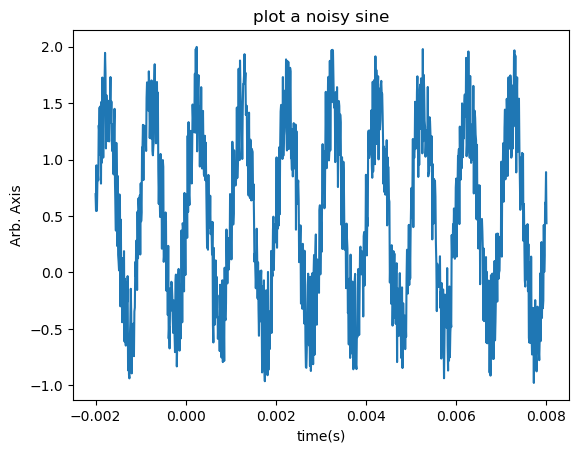

In [64]:
# This is easiest way to plot a figure, but not able to zoom in and measure
t = np.linspace(-2e-3, 8e-3, 1000)
f = 1000
y = np.sin(2*np.pi*f*t) + np.random.rand(len(t))
y = y0 + np.random.rand(len(t))
plt.plot(t,y)
plt.xlabel('time(s)')
plt.ylabel('Arb. Axis')
plt.title('plot a noisy sine')
plt.show()

####  <font color='green'>Task</font>: Plot in a single figure a sine wave with f=1000, f=2000 and f=3000.

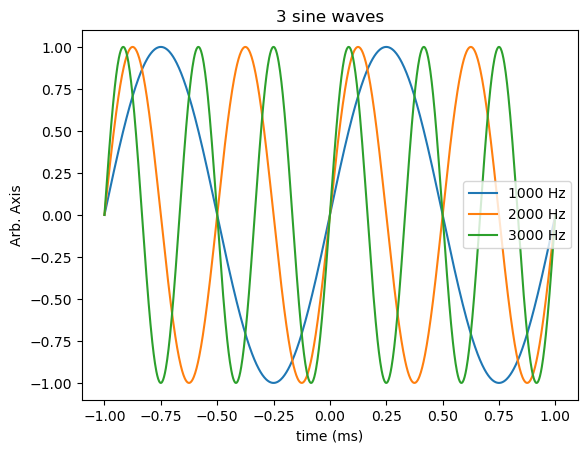

In [67]:
# This is easiest way to plot a figure, but not able to zoom in and measure
t = np.linspace(-1e-3,1e-3,1000) # smaller time axis again to see the sines properly
f = 1000
for f in [1000, 2000, 3000]:
    y = np.sin(2*np.pi*f*t)
    plt.plot(t*1e3, y, label=f'{f} Hz') # putting f before the string allows us to input variables inside of {} brackets
plt.xlabel('time (ms)')
plt.ylabel('Arb. Axis')
plt.title('3 sine waves')
plt.legend()

#### 6.3 Interactive Plot (Optional)

In [55]:
# define a function that takes in A and B,x, and output a plot
def plotter(A,B):
    y = A*np.sin(B*x)
    plt.plot(x,y)
    plt.grid()
    plt.ylim(-10,10)
    plt.show()

In [56]:
x = np.linspace(0,2*np.pi,100)
# define the interactive plotting tool.
iplot = interactive(plotter, A=  (-3,10,0.1),B=(1,5,0.5))
iplot

interactive(children=(FloatSlider(value=3.0, description='A', max=10.0, min=-3.0), FloatSlider(value=3.0, desc…